# Libraries and Tools

NumPy Numerical Python

In [2]:
import numpy as np

a = np.array([1, 2, 3])
print(a)  # [1 2 3]
print(type(a))  

[1 2 3]
<class 'numpy.ndarray'>


In [3]:
a = np.array([[1, 2, 3], [4, 5, 6]])
print(a.shape)      # (2, 3)
print(a.reshape(3, 2))  # Reshape to 3x2

(2, 3)
[[1 2]
 [3 4]
 [5 6]]


In [5]:
b = np.array([10, 20, 30, 40])
print(b[1])   # 20
print(b[1:3]) # [20 30]

20
[20 30]


In [6]:
a = np.array([1, 2, 3])
b = 2
print(a + b)  # [3 4 5] – b is broadcasted

[3 4 5]


In [9]:
print(np.zeros((2,2)))   # [[0, 0], [0, 0]]
print(np.ones(3))      # [1. 1. 1.]
print(np.arange(5))      # [0, 1, 2, 3, 4]
print(np.mean(a))        # Mean of array
print(np.dot(a, a))      # Dot product

[[0. 0.]
 [0. 0.]]
[1. 1. 1.]
[0 1 2 3 4]
2.0
14


Pandas Data analysis library

In [10]:
import pandas as pd

s = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
print(s)

a    10
b    20
c    30
dtype: int64


In [11]:
data = {
    'Name': ['Ashesh', 'Ram'],
    'Age': [22, 24]
}

df = pd.DataFrame(data)
print(df)

     Name  Age
0  Ashesh   22
1     Ram   24


In [18]:
print(df['Name'])       # Access a column
print(df.iloc[0])       # Row by index
print(df.loc[0, 'Age']) # Specific cell

0    Ashesh
1       Ram
Name: Name, dtype: object
Name    Ashesh
Age         22
Name: 0, dtype: object
22


In [19]:
df[df['Age'] > 22]

,Name,Age
1,Ram,24


In [20]:
df.groupby('Age').count()

,Name
Age,
22,1
24,1


In [23]:
print(df.isnull().sum())            # Check nulls
df.fillna(0, inplace=True)   # Fill missing with 0
df.dropna(inplace=True)      # Drop missing rows

Name    0
Age     0
dtype: int64


Matplotib

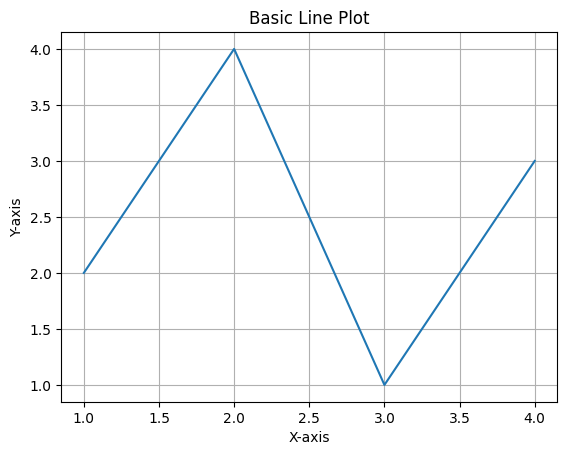

In [25]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4]
y = [2, 4, 1, 3]

plt.plot(x, y)
plt.title("Basic Line Plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.show()

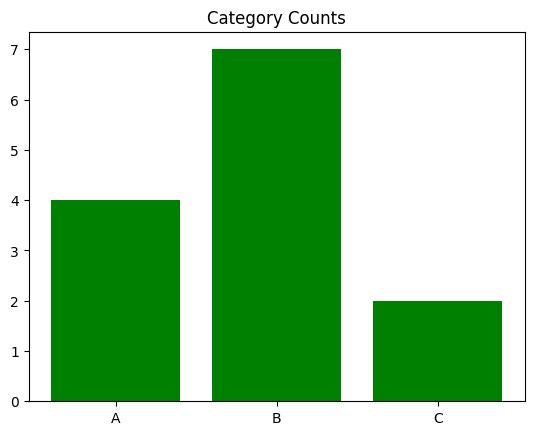

In [26]:
categories = ['A', 'B', 'C']
values = [4, 7, 2]

plt.bar(categories, values, color='green')
plt.title("Category Counts")
plt.show()

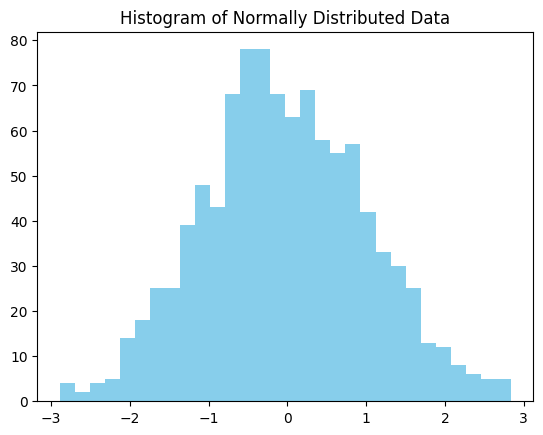

In [27]:
import numpy as np

data = np.random.randn(1000)

plt.hist(data, bins=30, color='skyblue')
plt.title("Histogram of Normally Distributed Data")
plt.show()

Seaborn

In [28]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('tips')  # Built-in dataset: restaurant bills

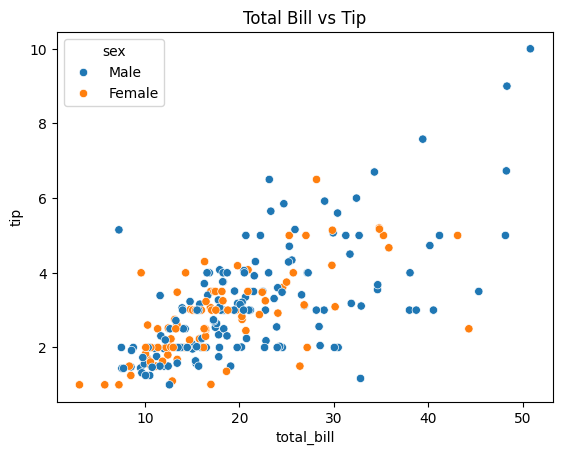

In [29]:
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex')
plt.title("Total Bill vs Tip")
plt.show()

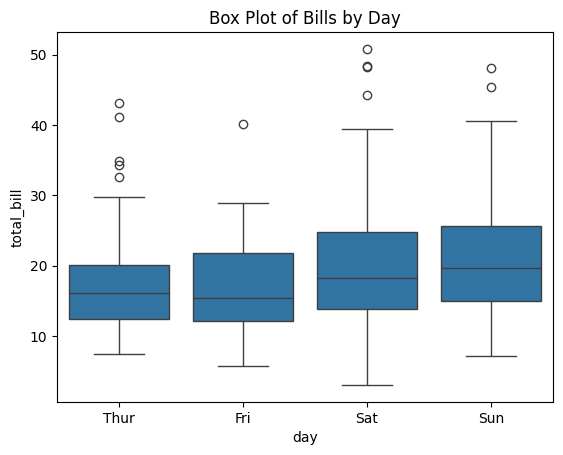

In [30]:
sns.boxplot(x='day', y='total_bill', data=df)
plt.title("Box Plot of Bills by Day")
plt.show()

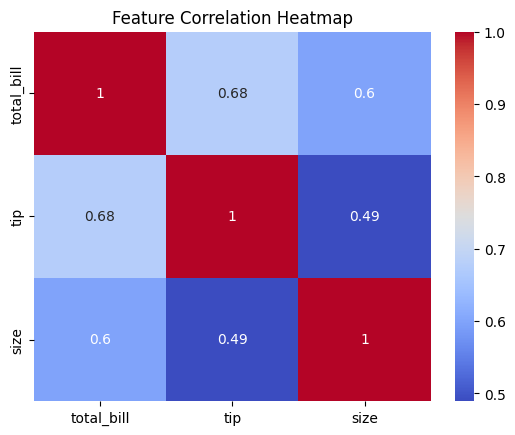

In [31]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

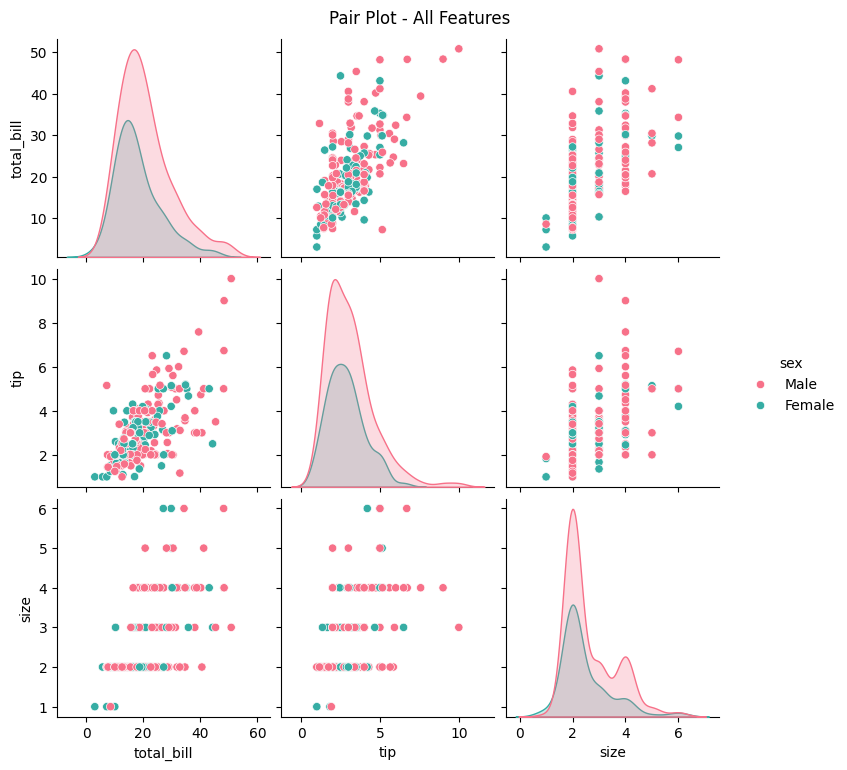

In [35]:
sns.pairplot(df, hue='sex', palette='husl')
plt.suptitle("Pair Plot - All Features", y=1.02)
plt.show()

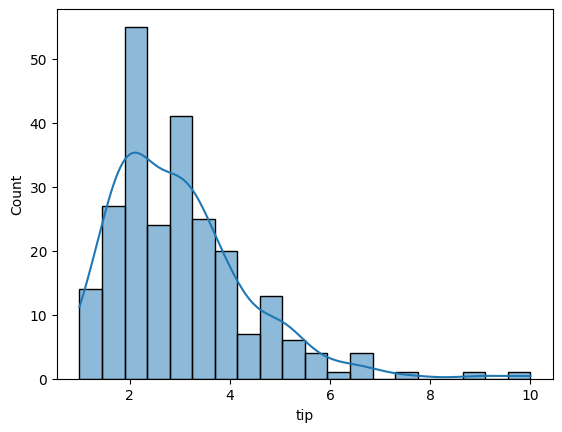

In [34]:
sns.histplot(df['tip'], bins=20, kde=True)
plt.show()

### Scikit-learn practical

1. Model Building

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 3441.209152420591
R2 Score: 0.4457641769904199


EXAMPLE 1: Linear Regression on Tips Dataset

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns

# Load dataset
df = sns.load_dataset('tips')

# Select features and target
X = df[['tip']]
y = df['total_bill']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 41.253481147484


 EXAMPLE 2: Classification — Logistic Regression on Titanic Dataset

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load Titanic dataset
df = sns.load_dataset('titanic')

# Drop missing
df = df[['sex', 'age', 'fare', 'survived']].dropna()

# Encode categorical
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Features and target
X = df[['sex', 'age', 'fare']]
y = df['survived']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Predict & Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7482517482517482


2. Model Evaluation

Classification metrics

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [6]:
accuracy_score(y_test, y_pred)

0.9555555555555556

In [15]:
print(precision_score(y_test, y_pred, average='macro'))
print(recall_score(y_test, y_pred, average='macro'))
print(f1_score(y_test, y_pred, average='macro'))

0.9558404558404558
0.9558404558404558
0.9558404558404558


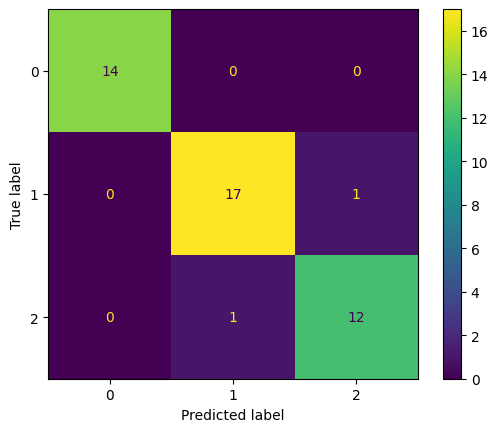

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

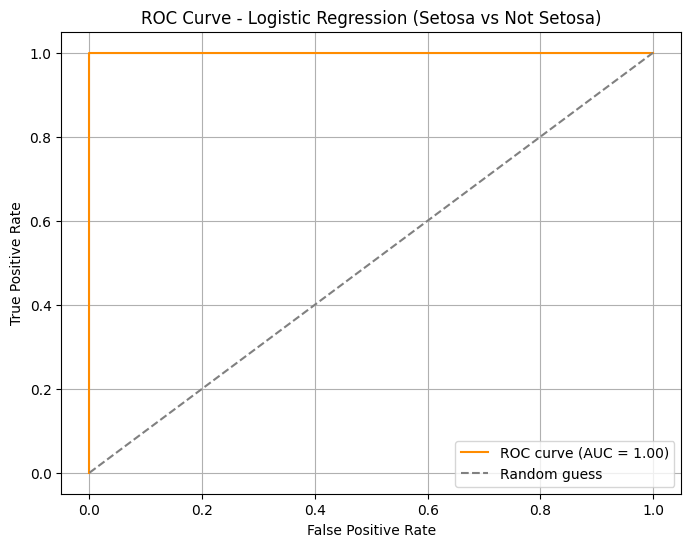

In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load the data
iris = load_iris()
X = iris.data
y = iris.target

# Step 2: Binary classification - Setosa vs Not Setosa
y_binary = np.where(y == 0, 1, 0)  # 1 = Setosa, 0 = Not Setosa

# Step 3: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Step 4: Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 5: Get predicted probabilities
y_pred_probs = model.predict_proba(X_test)[:, 1]

# Step 6: Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = roc_auc_score(y_test, y_pred_probs)

# Step 7: Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Setosa vs Not Setosa)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [6]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
# rmse = root_mean_squared_error(y_test, y_pred, squared=False)

In [10]:
mae

0.12615475412295435

In [11]:
mse

0.025039384459541198

In [13]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
scores

array([0.        , 0.85124923, 0.        , 0.76155439, 0.        ])

3. Pipelining

In [14]:
import seaborn as sns
import pandas as pd
data = sns.load_dataset('titanic')

# Select a subset for simplicity
df = data[['age', 'fare', 'sex', 'embarked', 'survived']].dropna()

X = df.drop('survived', axis=1)
y = df['survived']

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Column types
num_features = ['age', 'fare']
cat_features = ['sex', 'embarked']

# Preprocessing transformers
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder()

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Final pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Fit pipeline
pipeline.fit(X_train, y_train)

# Evaluate
print("Accuracy:", pipeline.score(X_test, y_test))

Accuracy: 0.7622377622377622
